# 04. Run inferCNV

This notebook runs the inferCNV analysis on both the raw and denoised data to compare the results and evaluate the performance of the masked autoencoder.

In [3]:
!pip install -r /content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/requirements.txt

INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 12.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.3/185.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 2.9 MB/s eta 0

In [7]:
import os
os.sys.path.append('../src')
import infercnvpy as cnv
import scanpy as sc
import anndata as ad
import torch
from clearcnv.model import MaskedAutoencoder

## 1. Load Data and Model

In [13]:
# Load the AnnData object with the raw data
adata = ad.read_h5ad("../datasets/Xenium5K_human_prostate_subset.h5ad")

# Load the trained model
model_path = "../clearcnv_outputs/models/model_epoch_6.pt"  # Replace with the path to your best model
n_genes = adata.shape[1]
model = MaskedAutoencoder(n_genes=n_genes)
model.load_state_dict(torch.load(model_path))
model.eval()

# Denoise the data
with torch.no_grad():
    denoised_expression, _ = model(torch.tensor(adata.X.toarray()))

# Create a new AnnData object for the denoised data
adata_denoised = adata.copy()
adata_denoised.X = denoised_expression.numpy()

## 2. Run inferCNV on Raw Data

In [16]:
cnv.io.genomic_position_from_biomart(adata, adata_gene_id="gene_ids" ,species="hsapiens")

In [18]:
cnv.tl.infercnv(adata)

  0%|          | 0/2 [00:00<?, ?it/s]

## 3. Run inferCNV on Denoised Data

In [19]:
cnv.io.genomic_position_from_biomart(adata_denoised, adata_gene_id="gene_ids" ,species="hsapiens")
cnv.tl.infercnv(adata_denoised)

  0%|          | 0/2 [00:00<?, ?it/s]

## 4. Compare Results

In [21]:
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt
import infercnvpy as cnv

# PCA → neighbors → Leiden
for ad in [adata, adata_denoised]:
    cnv.tl.pca(ad, n_comps=30)
    cnv.pp.neighbors(ad, n_neighbors=15, n_pcs=30)
    cnv.tl.leiden(ad, resolution=0.5)

Adata


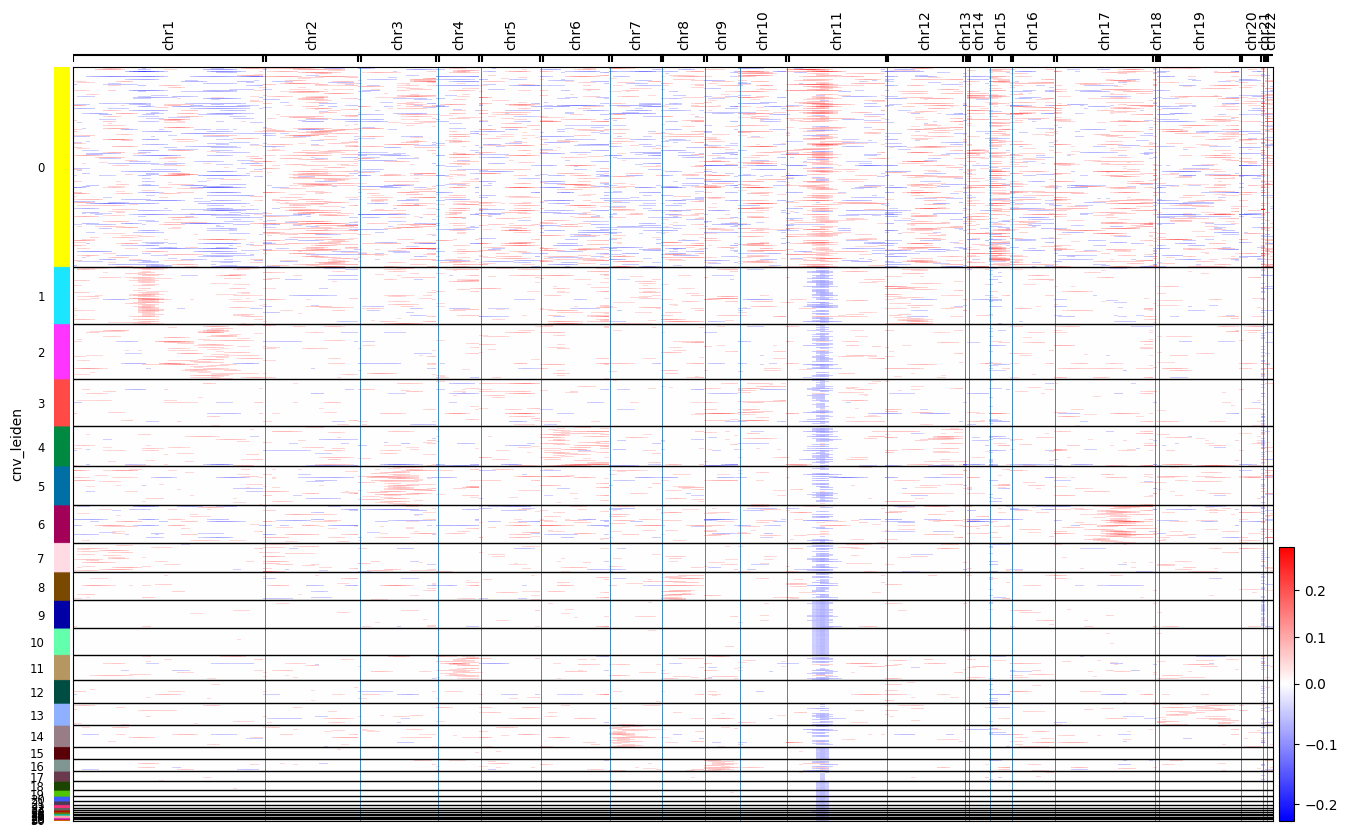

Adata_denoised


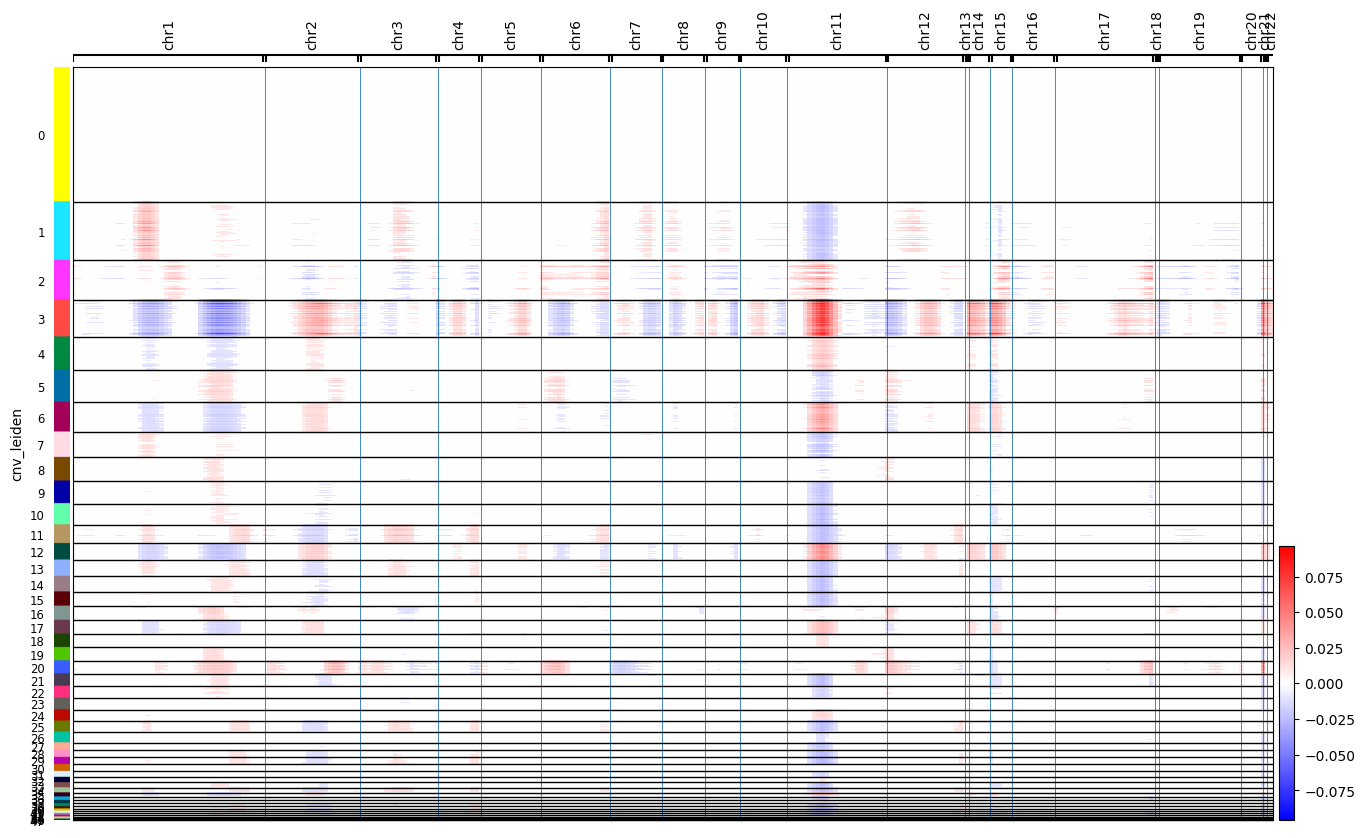

In [33]:
# Plot separately
print('Adata')
cnv.pl.chromosome_heatmap(adata)
print('Adata_denoised')
cnv.pl.chromosome_heatmap(adata_denoised)